# LSTM — wybór kryptowaluty na następną próbkę

Implementacja na podstawie `../classification_return/log_LSTM.ipynb`.
Model klasyfikuje, która z par **BTC/USDT, ETH/USDT, SOL/USDT, BNB/USDT**
uzyska największą stopę zwrotu w kolejnej godzinie. Binance oznacza tutaj token BNB.
Dla decyzji po zamknięciu świecy t wejściem jest 240 historycznych logarytmicznych
stóp zwrotu wszystkich czterech par, a etykietą `argmax(C[t+1] / C[t] - 1)`.
Softmax opisuje prawdopodobieństwo wygrania rankingu, nie prognozowaną wielkość zwrotu.
Remisy rozstrzyga kolejność par. Model zawsze wybiera jedną parę, także gdy wszystkie spadają.

In [1]:
import ccxt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from tensorflow.keras import Sequential, utils
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

utils.set_random_seed(42)

2026-09-19 15:57:38.672261: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
TICKERS = ["BTC/USDT", "ETH/USDT", "SOL/USDT", "BNB/USDT"]
CLIENT = ccxt.binance({"enableRateLimit": True})
TIMEFRAME = "1h"
STEP_MS = CLIENT.parse_timeframe(TIMEFRAME) * 1000
START_DATE = CLIENT.parse8601("2023-11-03T20:00:00Z")
END_DATE = CLIENT.parse8601("2026-03-31T20:00:00Z")  # granica wyłączna
LAGS_NUM = 240
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
HIDDEN_NEURONS_NUM = 50
EPOCHS_NUM = 100
BATCH_SIZE = 32
DROPOUT_RATE = 0.2
PATIENCE_NUM = 10
START_CASH = 1000.0
FEE_RATE = 0.001  # opłata jednej transakcji; zmiana pary = sprzedaż + zakup

## Pobranie i synchronizacja danych
Uwzględniamy tylko zamknięte świece we wskazanym przedziale. Braki danych przerywają
analizę — nie uzupełniamy cen ani nie traktujemy przerw jako jednej godziny.

In [3]:
def fetch_data(client, ticker, start_date, end_date, timeframe, step_ms):
    rows = []
    cursor = start_date
    while cursor < end_date:
        batch = client.fetch_ohlcv(ticker, timeframe=timeframe, since=cursor, limit=1000)
        if not batch:
            break
        next_cursor = max(row[0] for row in batch) + step_ms
        if next_cursor <= cursor:
            raise RuntimeError(f"Brak postępu pobierania: {ticker}")
        rows.extend(row for row in batch if start_date <= row[0] < end_date)
        cursor = next_cursor
    if not rows:
        raise ValueError(f"Brak danych: {ticker}")
    frame = pd.DataFrame(rows, columns=["Date", "Open", "High", "Low", "Close", "Volume"])
    frame["Date"] = pd.to_datetime(frame["Date"], unit="ms", utc=True)
    return frame.drop_duplicates("Date").set_index("Date").sort_index()


def align_closes(data_by_ticker, tickers, start_date, end_date, step_ms):
    expected = pd.date_range(
        pd.to_datetime(start_date, unit="ms", utc=True),
        pd.to_datetime(end_date, unit="ms", utc=True),
        freq=pd.Timedelta(milliseconds=step_ms), inclusive="left",
    )
    closes = pd.concat([data_by_ticker[t]["Close"].rename(t) for t in tickers], axis=1)
    closes = closes.reindex(expected)
    missing = closes.isna().sum()
    if missing.any():
        raise ValueError(f"Brak świec w żądanym zakresie:\n{missing[missing > 0]}")
    if not np.isfinite(closes.to_numpy()).all() or (closes <= 0).any().any():
        raise ValueError("Ceny muszą być dodatnie i skończone.")
    closes.index.name = "candle_open_time"
    return closes

# Identyczne granice dla wszystkich par; wykluczenie bieżącej, niezamkniętej świecy.
effective_end = min(END_DATE, CLIENT.milliseconds() // STEP_MS * STEP_MS)
raw_data = {
    ticker: fetch_data(CLIENT, ticker, START_DATE, effective_end, TIMEFRAME, STEP_MS)
    for ticker in TICKERS
}
close = align_closes(raw_data, TICKERS, START_DATE, effective_end, STEP_MS)
print(f"Liczba wspólnych świec: {len(close)}")
display(close.head())

Liczba wspólnych świec: 21096


,BTC/USDT,ETH/USDT,SOL/USDT,BNB/USDT
candle_open_time,,,,
2023-11-03 20:00:00+00:00,34593.90,1827.95,39.50,229.7
2023-11-03 21:00:00+00:00,34600.93,1826.76,39.38,229.9
2023-11-03 22:00:00+00:00,34628.14,1831.20,39.74,230.3
2023-11-03 23:00:00+00:00,34716.78,1832.71,39.45,230.2
2023-11-04 00:00:00+00:00,34696.65,1828.13,39.26,229.6


## Sekwencje i chronologiczny podział 70% / 15% / 15%
Indeks próbki wskazuje świecę, której zwrot prognozujemy. Jej cena nie trafia do wejścia.
Skaler dopasowujemy tylko do obserwacji wykorzystanych jako wejścia treningowe.
Walidacja i test mogą korzystać z wcześniejszej historii, tak jak podczas pracy na żywo.

In [4]:
def prepare_samples(close, lags_num, train_ratio=0.70, val_ratio=0.15):
    if lags_num < 1 or not (0 < train_ratio < 1 and 0 < val_ratio < 1 - train_ratio):
        raise ValueError("Nieprawidłowe długości okien lub proporcje podziału.")
    log_returns = np.log(close / close.shift(1)).iloc[1:]
    simple_returns = close.pct_change(fill_method=None).iloc[1:]
    target_positions = np.arange(lags_num, len(log_returns))
    n = len(target_positions)
    train_end = int(n * train_ratio)
    val_end = int(n * (train_ratio + val_ratio))
    if not (0 < train_end < val_end < n):
        raise ValueError("Za mało danych na niepuste zbiory treningowy, walidacyjny i testowy.")
    scaler = StandardScaler()
    # Ostatnia etykieta treningowa nie jest wejściem treningowym.
    scaler.fit(log_returns.iloc[:target_positions[train_end - 1]])
    values = scaler.transform(log_returns).astype(np.float32)
    X = np.stack([values[i-lags_num:i] for i in target_positions])
    returns = simple_returns.iloc[target_positions].copy()
    y = returns.to_numpy().argmax(axis=1).astype(np.int32)
    splits = {"train": slice(0, train_end), "val": slice(train_end, val_end), "test": slice(val_end, n)}
    return X, y, returns, splits, scaler

X, y, future_returns, splits, scaler = prepare_samples(close, LAGS_NUM, TRAIN_RATIO, VAL_RATIO)
X_train, y_train = X[splits["train"]], y[splits["train"]]
X_val, y_val = X[splits["val"]], y[splits["val"]]
X_test, y_test = X[splits["test"]], y[splits["test"]]
for name, part in splits.items():
    dates = future_returns.index[part]
    print(f"{name}: {X[part].shape}, prognozowane świece {dates[0]} — {dates[-1]}")
display(pd.Series(np.bincount(y_train, minlength=len(TICKERS)), index=TICKERS, name="Etykiety treningowe"))

train: (14598, 240, 4), prognozowane świece 2023-11-13 21:00:00+00:00 — 2025-07-14 02:00:00+00:00
val: (3128, 240, 4), prognozowane świece 2025-07-14 03:00:00+00:00 — 2025-11-21 10:00:00+00:00
test: (3129, 240, 4), prognozowane świece 2025-11-21 11:00:00+00:00 — 2026-03-31 19:00:00+00:00


BTC/USDT    3166
ETH/USDT    2861
SOL/USDT    4879
BNB/USDT    3692
Name: Etykiety treningowe, dtype: int64

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        11,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │           204 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,204 (43.77 KB)

 Trainable params: 11,204 (43.77 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
457/457 ━━━━━━━━━━━━━━━━━━━━ 25s 50ms/step - accuracy: 0.3313 - loss: 1.3658 - val_accuracy: 0.2973 - val_loss: 1.3852
Epoch 2/100
457/457 ━━━━━━━━━━━━━━━━━━━━ 25s 54ms/step - accuracy: 0.3367 - loss: 1.3630 - val_accuracy: 0.2983 - val_loss: 1.3840
Epoch 3/100
457/457 ━━━━━━━━━━━━━━━━━━━━ 24s 53ms/step - accuracy: 0.3359 - loss: 1.3619 - val_accuracy: 0.2989 - val_loss: 1.3833
Epoch 4/100
457/457 ━━━━━━━━━━━━━━━━━━━━ 30s 66ms/step - accuracy: 0.3355 - loss: 1.3612 - val_accuracy: 0.2980 - val_loss: 1.3828
Epoch 5/100
457/457 ━━━━━━━━━━━━━━━━━━━━ 26s 58ms/step - accuracy: 0.3366 - loss: 1.3603 - val_accuracy: 0.2973 - val_loss: 1.3827
Epoch 6/100
457/457 ━━━━━━━━━━━━━━━━━━━━ 26s 57ms/step - accuracy: 0.3349 - loss: 1.3603 - val_accuracy: 0.2986 - val_loss: 1.3828
Epoch 7/100
457/457 ━━━━━━━━━━━━━━━━━━━━ 31s 68ms/step - accuracy: 0.3404 - loss: 1.3586 - val_accuracy: 0.2970 - val_loss: 1.3833
Epoch 8/100
457/457 ━━━━━━━━━━━━━━━━━━━━ 30s 66ms/step - accuracy: 0.3381 - loss: 1

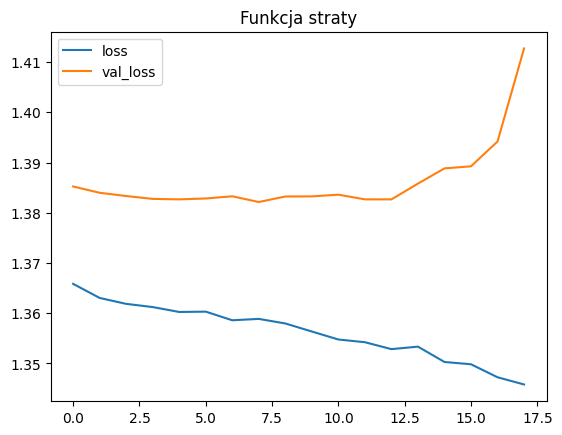

In [5]:
model = Sequential([
    Input(shape=(LAGS_NUM, len(TICKERS))),
    LSTM(HIDDEN_NEURONS_NUM),
    Dropout(DROPOUT_RATE),
    Dense(len(TICKERS), activation="softmax"),
])
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.summary()
history = model.fit(
    X_train, y_train, validation_data=(X_val, y_val),
    epochs=EPOCHS_NUM, batch_size=BATCH_SIZE, shuffle=False,
    callbacks=[EarlyStopping(monitor="val_loss", patience=PATIENCE_NUM, restore_best_weights=True)],
)
pd.DataFrame(history.history)[["loss", "val_loss"]].plot(title="Funkcja straty")
plt.show()

## Ocena wyboru pary na zbiorze testowym

              precision    recall  f1-score   support

    BTC/USDT       0.00      0.00      0.00       654
    ETH/USDT       0.24      0.03      0.05       691
    SOL/USDT       0.29      0.94      0.45       915
    BNB/USDT       0.30      0.03      0.06       869

    accuracy                           0.29      3129
   macro avg       0.21      0.25      0.14      3129
weighted avg       0.22      0.29      0.16      3129

Trafność stałego wyboru najczęstszej klasy treningowej (SOL/USDT): 0.292


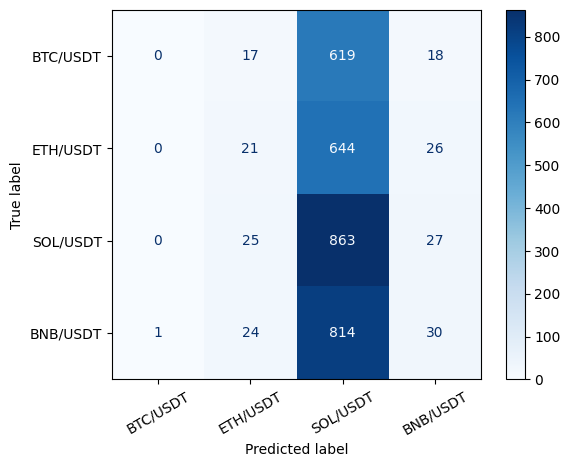

Średnia różnica do najlepszego zwrotu: 0.002432


,decision_time,return_end_time,selected_pair,actual_best_pair,probability,selected_return,best_return,regret
candle_open_time,,,,,,,,
2025-11-21 11:00:00+00:00,2025-11-21 11:00:00+00:00,2025-11-21 12:00:00+00:00,SOL/USDT,ETH/USDT,0.370787,-0.006156,-0.003107,0.003048
2025-11-21 12:00:00+00:00,2025-11-21 12:00:00+00:00,2025-11-21 13:00:00+00:00,SOL/USDT,SOL/USDT,0.368190,0.015524,0.015524,0.000000
2025-11-21 13:00:00+00:00,2025-11-21 13:00:00+00:00,2025-11-21 14:00:00+00:00,SOL/USDT,BTC/USDT,0.316724,0.007604,0.009965,0.002361
2025-11-21 14:00:00+00:00,2025-11-21 14:00:00+00:00,2025-11-21 15:00:00+00:00,SOL/USDT,SOL/USDT,0.304651,0.011084,0.011084,0.000000
2025-11-21 15:00:00+00:00,2025-11-21 15:00:00+00:00,2025-11-21 16:00:00+00:00,ETH/USDT,BNB/USDT,0.281038,-0.023474,-0.017912,0.005562
2025-11-21 16:00:00+00:00,2025-11-21 16:00:00+00:00,2025-11-21 17:00:00+00:00,SOL/USDT,SOL/USDT,0.336685,0.025915,0.025915,0.000000
2025-11-21 17:00:00+00:00,2025-11-21 17:00:00+00:00,2025-11-21 18:00:00+00:00,SOL/USDT,ETH/USDT,0.324494,0.004353,0.006399,0.002047
2025-11-21 18:00:00+00:00,2025-11-21 18:00:00+00:00,2025-11-21 19:00:00+00:00,SOL/USDT,SOL/USDT,0.302833,0.002476,0.002476,0.000000
2025-11-21 19:00:00+00:00,2025-11-21 19:00:00+00:00,2025-11-21 20:00:00+00:00,SOL/USDT,BNB/USDT,0.297897,-0.010962,-0.002959,0.008003


In [6]:
probabilities = model.predict(X_test, verbose=0)
y_pred = probabilities.argmax(axis=1)
print(classification_report(y_test, y_pred, labels=np.arange(len(TICKERS)), target_names=TICKERS, zero_division=0))
majority_class = np.bincount(y_train, minlength=len(TICKERS)).argmax()
print(f"Trafność stałego wyboru najczęstszej klasy treningowej ({TICKERS[majority_class]}): {(y_test == majority_class).mean():.3f}")
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, labels=np.arange(len(TICKERS)), display_labels=TICKERS, cmap="Blues",
)
plt.xticks(rotation=30)
plt.show()

test_returns = future_returns.iloc[splits["test"]]
results = pd.DataFrame(index=test_returns.index)
results["decision_time"] = results.index  # zamknięcie poprzedniej świecy = początek docelowej
results["return_end_time"] = results.index + pd.Timedelta(milliseconds=STEP_MS)
results["selected_pair"] = np.asarray(TICKERS)[y_pred]
results["actual_best_pair"] = np.asarray(TICKERS)[y_test]
results["probability"] = probabilities.max(axis=1)
results["selected_return"] = test_returns.to_numpy()[np.arange(len(y_pred)), y_pred]
results["best_return"] = test_returns.max(axis=1)
results["regret"] = results["best_return"] - results["selected_return"]
print(f"Średnia różnica do najlepszego zwrotu: {results['regret'].mean():.6f}")
display(results.head(10))

## Backtest
Cały kapitał jest utrzymywany w wybranej parze przez jedną próbkę. Przy zmianie pary
naliczamy sprzedaż i zakup, przy pozostaniu w tej samej parze brak transakcji.
Uwzględniamy też pierwszy zakup i końcową sprzedaż. Benchmark każdej pary to buy-and-hold.
Portfel równoważony co godzinę pokazujemy bez kosztów, podobnie jak teoretyczny wybór
najlepszej pary z wiedzą o przyszłości (oracle). Oracle nie jest osiągalną strategią.
Zakładamy wykonanie po cenie zamknięcia t, bez poślizgu i opóźnienia — to uproszczenie.

,Kapitał końcowy USDT,Stopa zwrotu %,Maksymalne obsunięcie %
LSTM netto,4.259745e+02,-57.402548,-62.037975
LSTM brutto,5.926148e+02,-40.738518,-48.698767
Buy & hold BTC/USDT netto,8.186244e+02,-18.137563,-35.589760
Buy & hold ETH/USDT netto,7.758636e+02,-22.413638,-46.449859
Buy & hold SOL/USDT netto,6.598024e+02,-34.019760,-48.813720
Buy & hold BNB/USDT netto,7.564396e+02,-24.356042,-39.087474
Równe wagi brutto,7.582269e+02,-24.177311,-42.133748
Oracle brutto,1.216888e+06,121588.849314,-7.273069


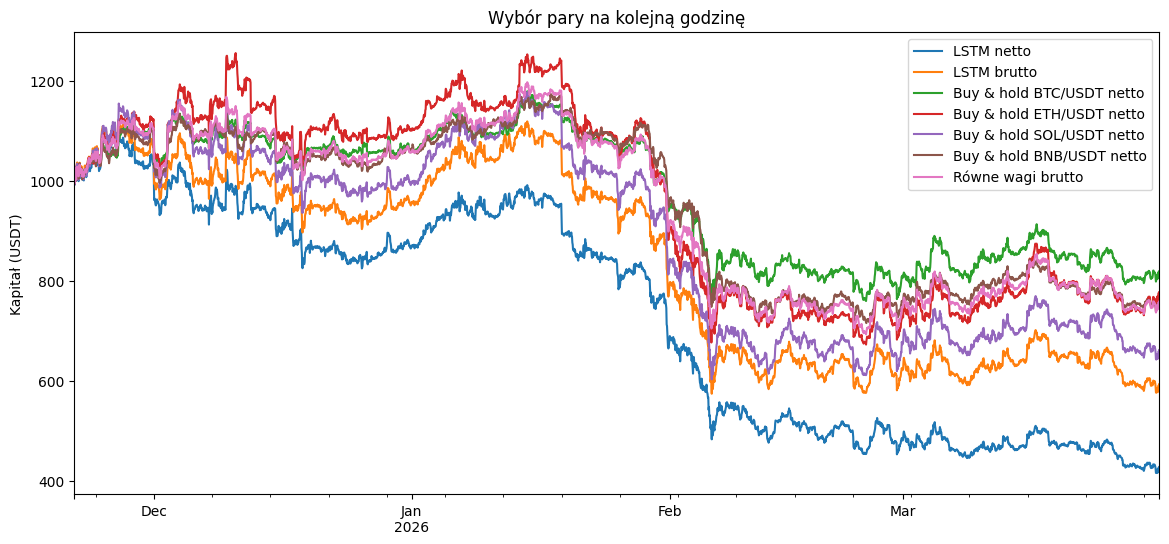

In [7]:
def strategy_returns(returns, choices, fee_rate):
    choices = np.asarray(choices, dtype=int)
    if not 0 <= fee_rate < 1 or len(returns) != len(choices) or len(choices) == 0:
        raise ValueError("Nieprawidłowe parametry backtestu.")
    selected = np.asarray(returns)[np.arange(len(choices)), choices]
    trades = np.zeros(len(choices), dtype=int)
    trades[0] = 1
    trades[1:] = 2 * (choices[1:] != choices[:-1])
    trades[-1] += 1
    return (1 + selected) * (1 - fee_rate) ** trades - 1

net_returns = strategy_returns(test_returns, y_pred, FEE_RATE)
results["net_return"] = net_returns
curves = pd.DataFrame(index=test_returns.index + pd.Timedelta(milliseconds=STEP_MS))
curves["LSTM netto"] = START_CASH * np.cumprod(1 + net_returns)
curves["LSTM brutto"] = START_CASH * np.cumprod(1 + results["selected_return"].to_numpy())
for i, ticker in enumerate(TICKERS):
    benchmark = strategy_returns(test_returns, np.full(len(test_returns), i), FEE_RATE)
    curves[f"Buy & hold {ticker} netto"] = START_CASH * np.cumprod(1 + benchmark)
curves["Równe wagi brutto"] = START_CASH * np.cumprod(1 + test_returns.mean(axis=1).to_numpy())
curves["Oracle brutto"] = START_CASH * np.cumprod(1 + results["best_return"].to_numpy())
initial = pd.DataFrame(START_CASH, index=[test_returns.index[0]], columns=curves.columns)
curves = pd.concat([initial, curves])
summary = pd.DataFrame({
    "Kapitał końcowy USDT": curves.iloc[-1],
    "Stopa zwrotu %": (curves.iloc[-1] / START_CASH - 1) * 100,
    "Maksymalne obsunięcie %": (curves / curves.cummax() - 1).min() * 100,
})
display(summary)
curves.drop(columns="Oracle brutto").plot(figsize=(14, 6), ylabel="Kapitał (USDT)", title="Wybór pary na kolejną godzinę")
plt.show()

## Wybór dla kolejnej, nieznanej próbki
Prognoza dotyczy godziny po ostatniej zamkniętej świecy pobranego zakresu.
Nie znamy jeszcze jej rzeczywistego zwrotu; przy historycznej dacie końcowej nie jest to sygnał bieżący.

In [8]:
latest_returns = np.log(close / close.shift(1)).iloc[-LAGS_NUM:]
latest_X = scaler.transform(latest_returns).astype(np.float32)[None, :, :]
next_probabilities = model.predict(latest_X, verbose=0)[0]
next_pair = TICKERS[int(next_probabilities.argmax())]
decision_time = close.index[-1] + pd.Timedelta(milliseconds=STEP_MS)
print(f"Wybór: {next_pair}, okres: {decision_time} — {decision_time + pd.Timedelta(milliseconds=STEP_MS)}")
display(pd.Series(next_probabilities, index=TICKERS, name="Prawdopodobieństwo największego zwrotu").sort_values(ascending=False))

Wybór: SOL/USDT, okres: 2026-03-31 20:00:00+00:00 — 2026-03-31 21:00:00+00:00


SOL/USDT    0.290774
ETH/USDT    0.262103
BNB/USDT    0.247244
BTC/USDT    0.199879
Name: Prawdopodobieństwo największego zwrotu, dtype: float32